In [223]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [224]:
def display(img, cmap="gray"):
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap="gray")

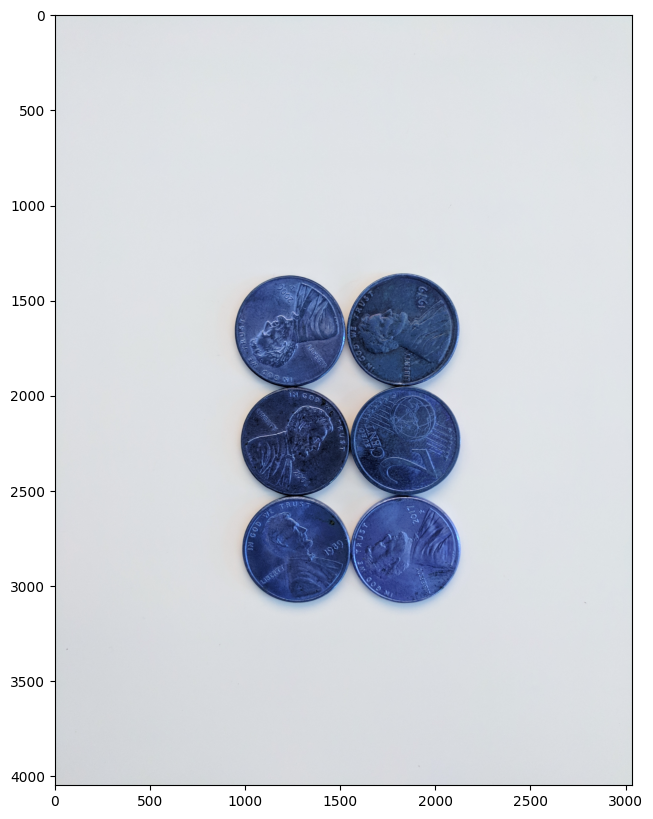

In [225]:
# This does not implement watershed algorithm. It is just showing some issues that exist without using it.
# In part 2 the watershed algorithm is used.
sep_coins = cv2.imread("../DATA/pennies.jpg")
display(sep_coins)

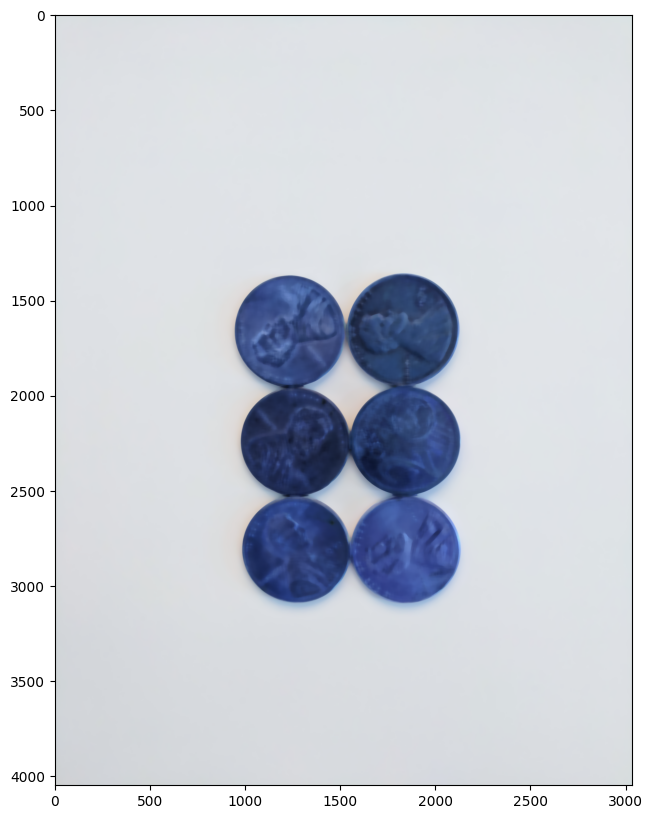

In [226]:
sep_blur = cv2.medianBlur(sep_coins, 25)
display(sep_blur)

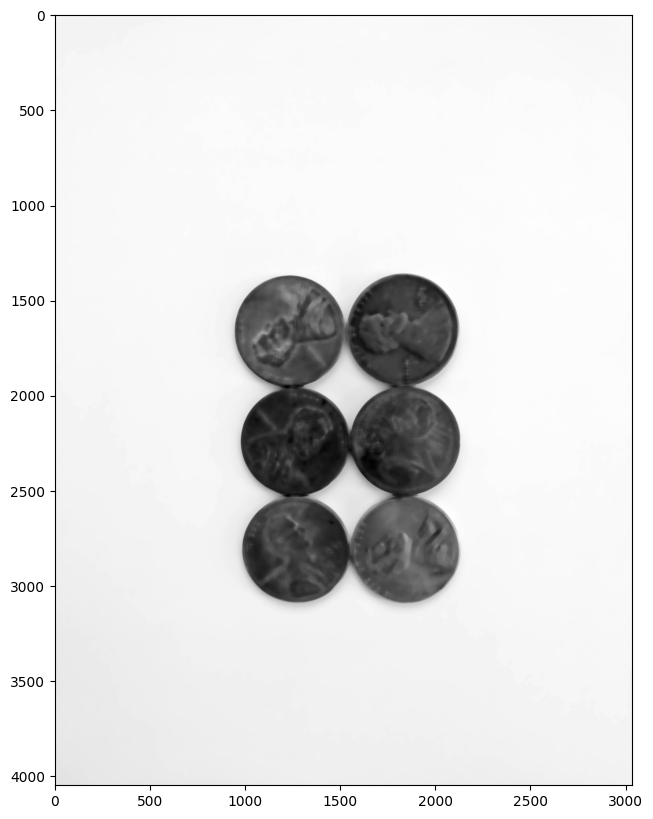

In [227]:
gray_sep_coints= cv2.cvtColor(sep_blur, cv2.COLOR_BGR2GRAY)
display(gray_sep_coints)

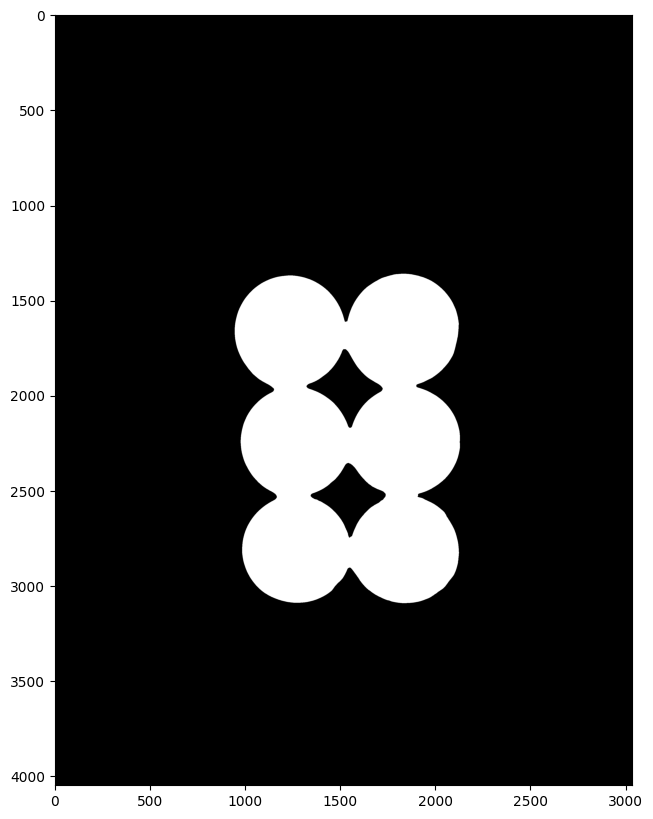

In [228]:
ret, sep_thresh = cv2.threshold(gray_sep_coints, 160, 255, cv2.THRESH_BINARY_INV)
display(sep_thresh)

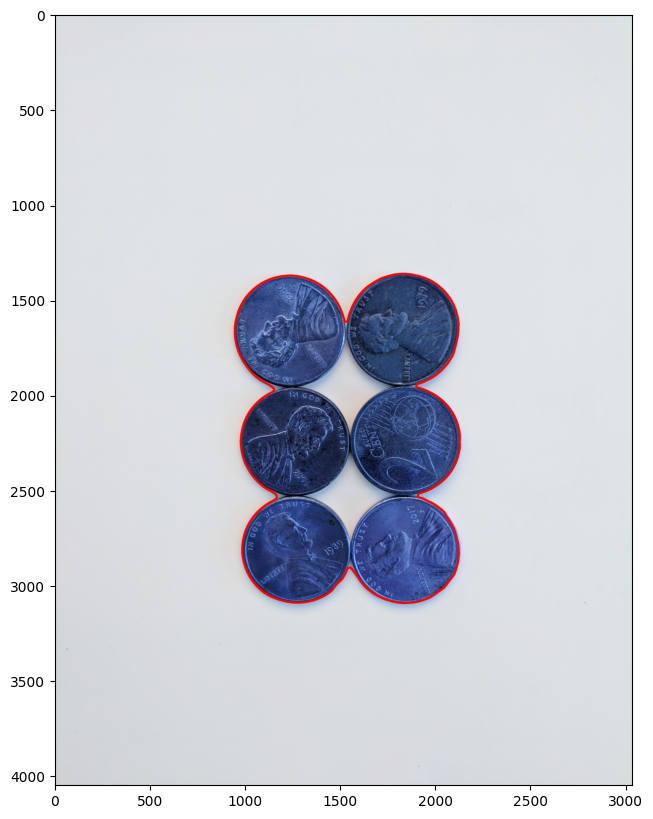

In [229]:
contours, hiearchy = cv2.findContours(sep_thresh.copy(), cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
for i in range(len(contours)):
    if hiearchy[0][i][3] == -1:
        cv2.drawContours(sep_coins, contours, i, (255, 0, 0), thickness=10)
display(sep_coins)

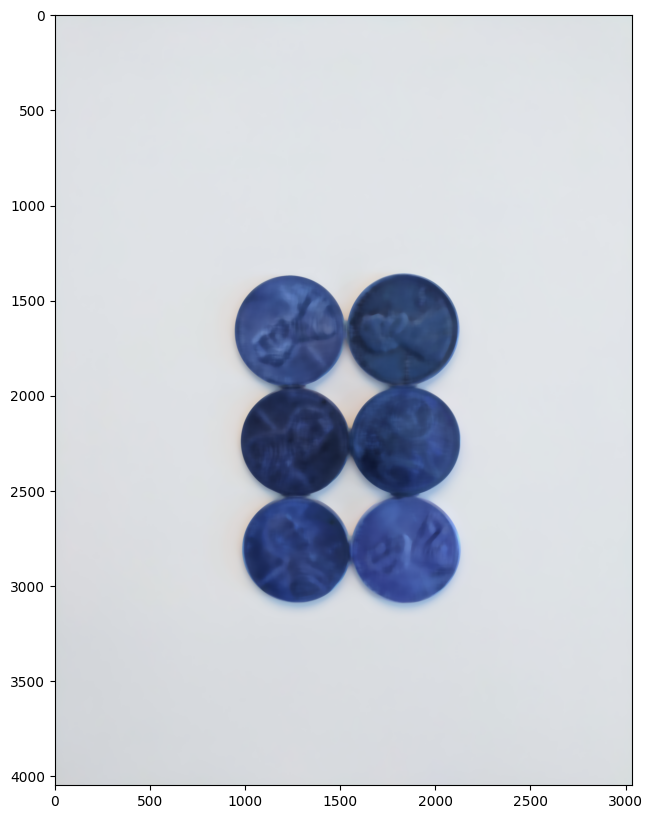

In [230]:
img = cv2.imread("../DATA/pennies.jpg")
img = cv2.medianBlur(img, 35)
display(img)


In [231]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

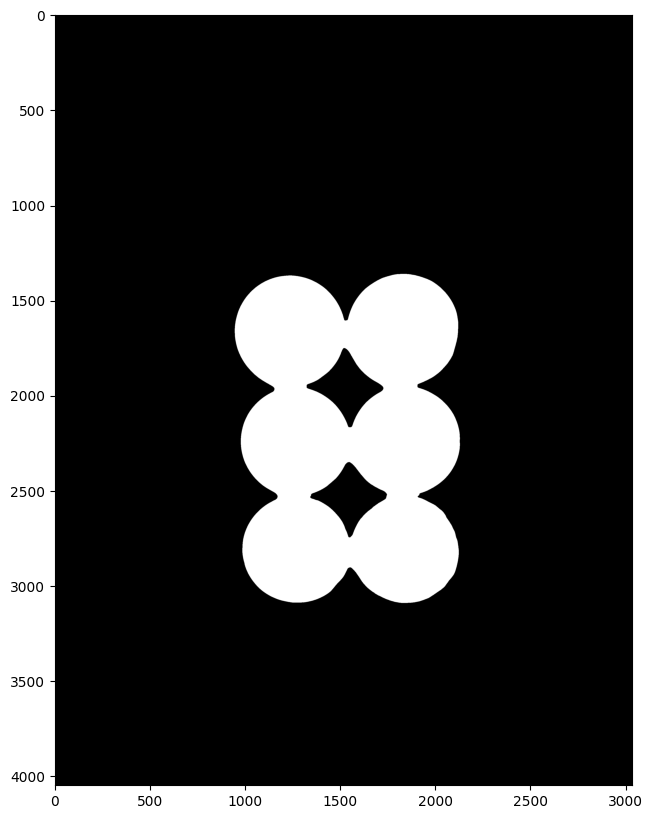

In [232]:
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
display(thresh)

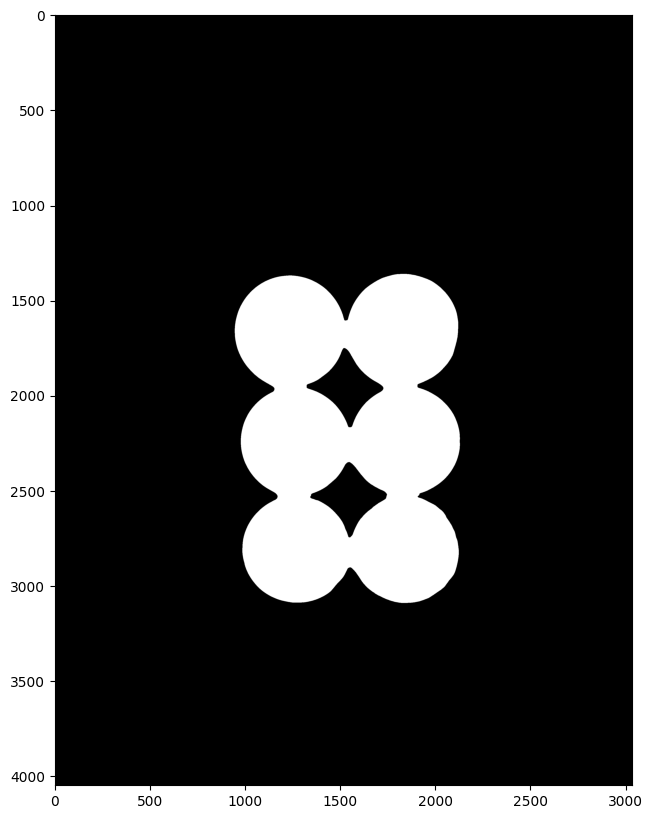

In [233]:
kernel = np.ones((3,3), np.uint8)
#optional for a simple image like this
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
display(opening)

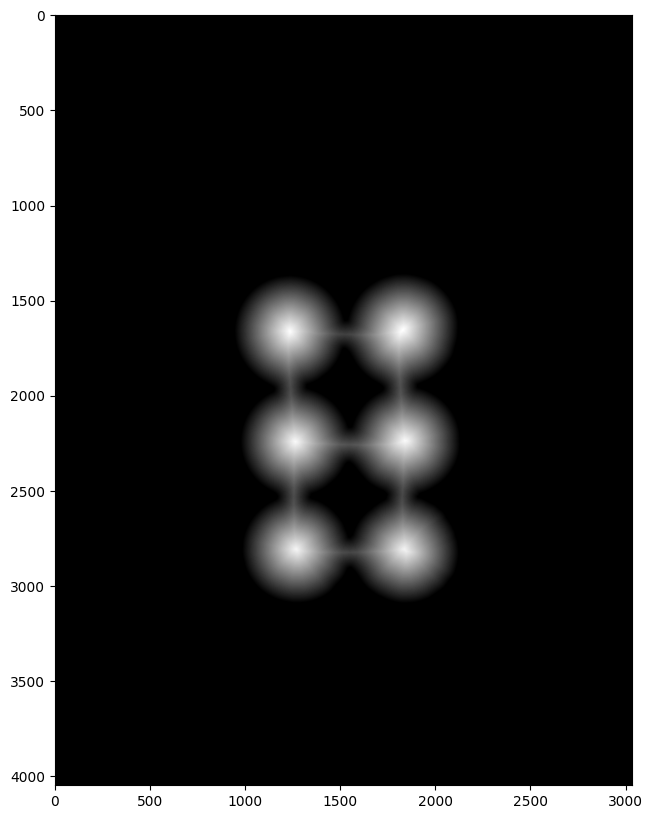

In [234]:
sure_bg = cv2.dilate(opening, kernel, iterations=3)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
display(dist_transform)

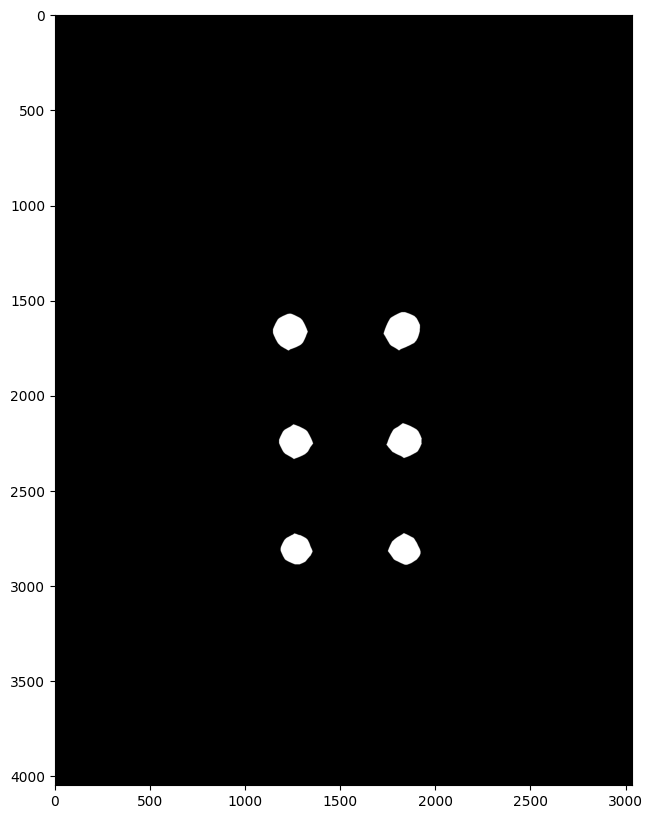

In [235]:
ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
display(sure_fg)

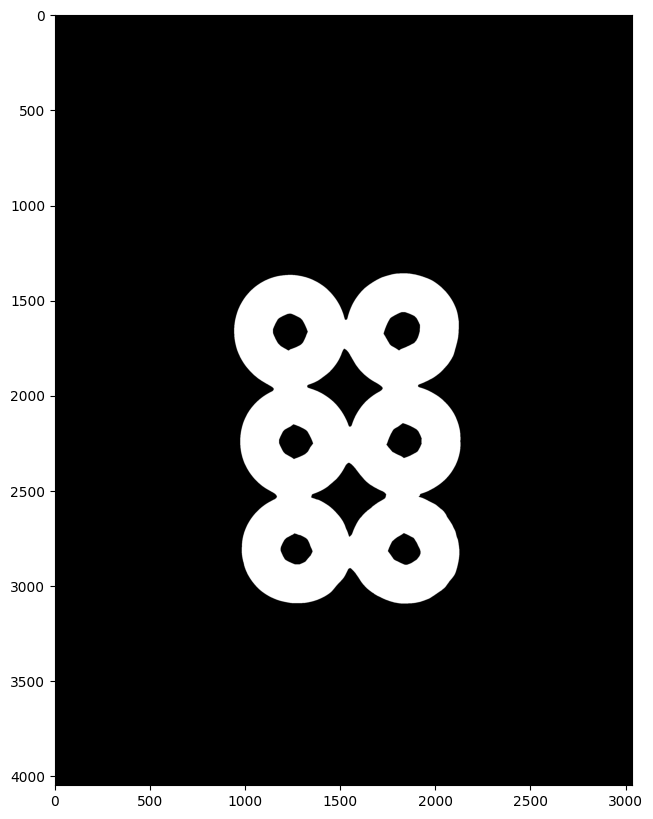

In [236]:
sure_fg = np.uint8(sure_fg)
unknown_region = cv2.subtract(sure_bg, sure_fg)
display(unknown_region)

In [237]:
ret, markers = cv2.connectedComponents(sure_fg, )

In [238]:
markers = markers + 1

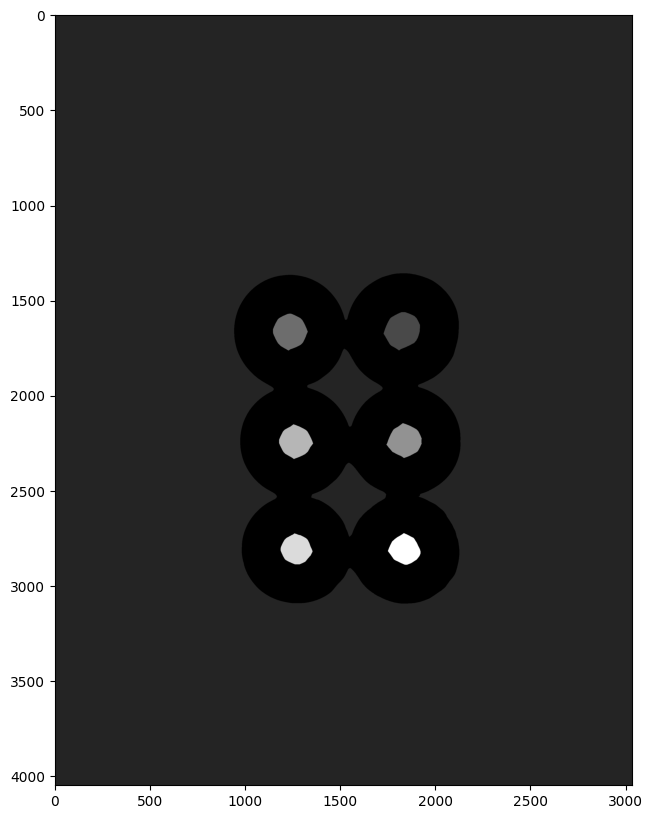

In [239]:
markers[unknown_region==255] = 0
display(markers)

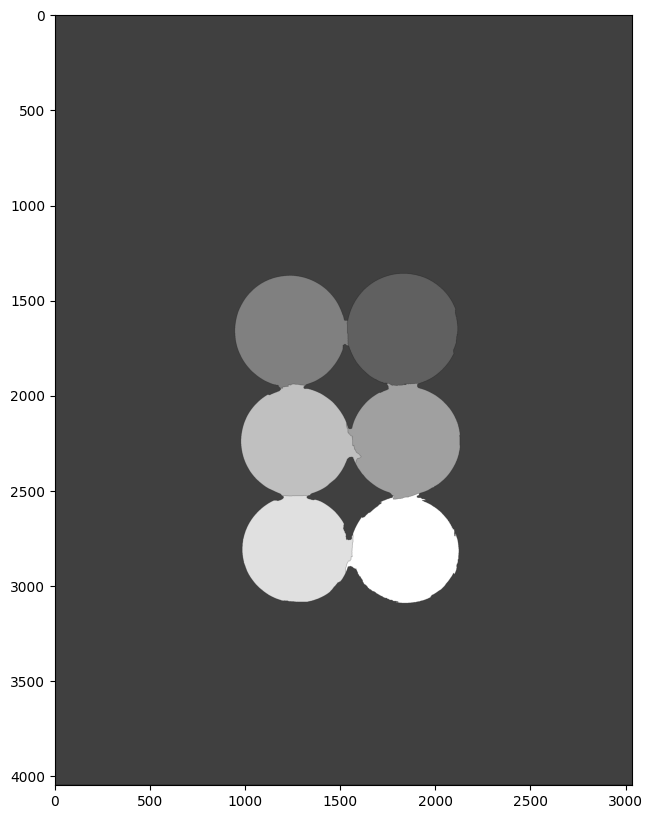

In [240]:
markers = cv2.watershed(img, markers)
display(markers)

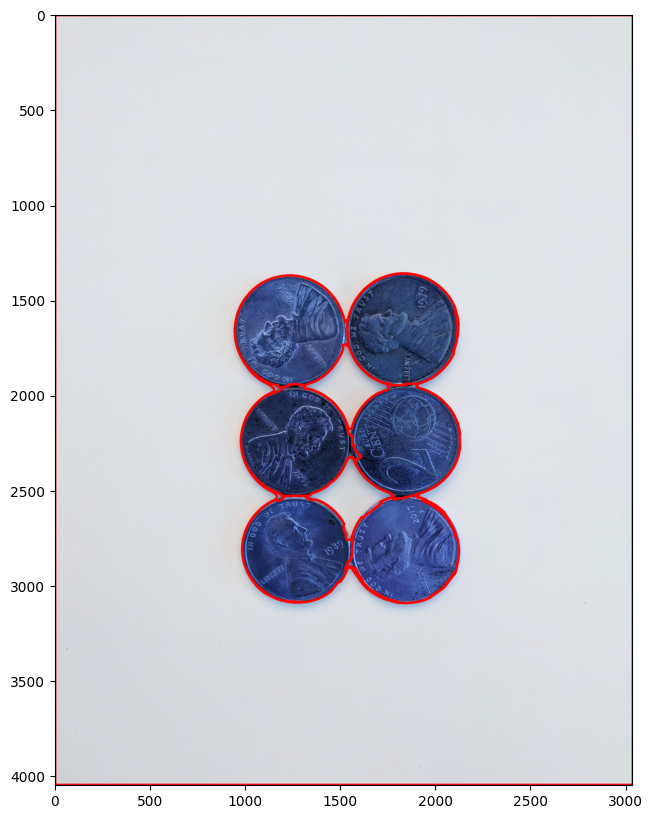

In [241]:
contours, hiearchy = cv2.findContours(markers.copy(), cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
for i in range(len(contours)):
    if hiearchy[0][i][3] == -1:
        cv2.drawContours(sep_coins, contours, i, (255, 0, 0), thickness=10)
display(sep_coins)